In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten ,BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError, MeanAbsoluteError
from tensorflow.keras.metrics import MeanAbsoluteError, MeanSquaredError, Accuracy
from imblearn.over_sampling import SMOTE


In [2]:
path=r"C:\Users\mrtat\Downloads\DL task\dataset\Rent.csv"
df=pd.read_csv(path)

In [3]:
df.head()

,BHK,Size,Floor,Area Locality,City,Bathroom,N_11,N_12,N_13,N_14,N_15,N_16,N_17,N_18,N_19,N_20,N_21,N_22,Rent
0,2,1100.000000,454,220,4,2,0,0,1,0,0,1,0,1,0,0,0,1,10000
1,2,967.936049,14,1525,4,1,0,0,1,0,1,0,0,1,0,0,0,1,20000
2,2,1000.000000,14,1758,4,1,0,0,1,0,1,0,0,1,0,0,0,1,17000
3,2,967.936049,10,525,4,1,0,0,1,0,0,1,0,1,0,0,0,1,10000
4,2,850.000000,10,1888,4,1,0,1,0,0,0,1,1,0,0,0,0,1,7500


In [4]:
for n in range (11,23):
    df.drop([f'N_{n}'], axis=1, inplace=True)

In [5]:
df.isna().sum().sort_values(ascending=False)

BHK              0
Size             0
Floor            0
Area Locality    0
City             0
Bathroom         0
Rent             0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(9)

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4718 entries, 0 to 4726
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   BHK            4718 non-null   int64  
 1   Size           4718 non-null   float64
 2   Floor          4718 non-null   int64  
 3   Area Locality  4718 non-null   int64  
 4   City           4718 non-null   int64  
 5   Bathroom       4718 non-null   int64  
 6   Rent           4718 non-null   int64  
dtypes: float64(1), int64(6)
memory usage: 294.9 KB


In [9]:
df.shape

(4718, 7)

In [10]:
cols = list(df.nunique().sort_values().index[:3])
cols

['BHK', 'City', 'Bathroom']

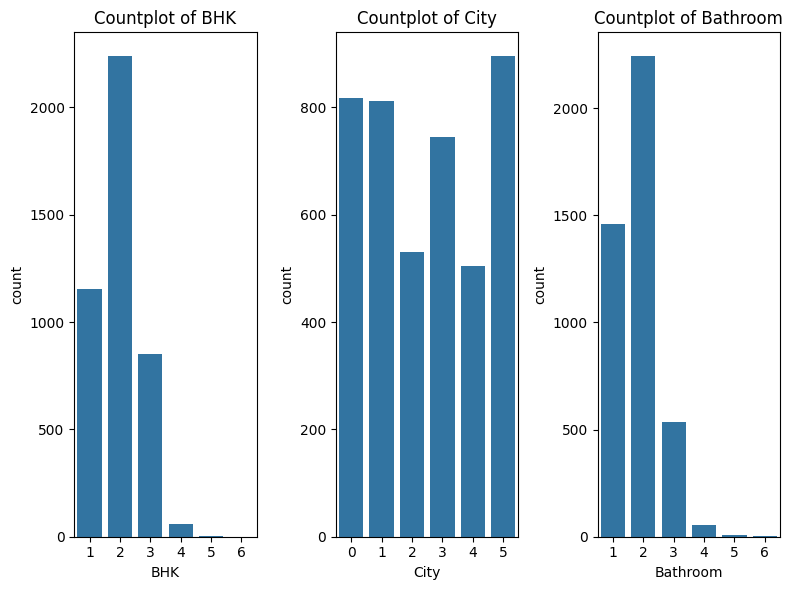

In [30]:

plt.figure(figsize=(8, 6))
for n, col in enumerate(cols):
    plt.subplot(1, 3, n + 1)
    sns.countplot(data=df, x=col)
    plt.title(f'Countplot of {col}')

plt.tight_layout()
    

<Axes: xlabel='Size', ylabel='Count'>

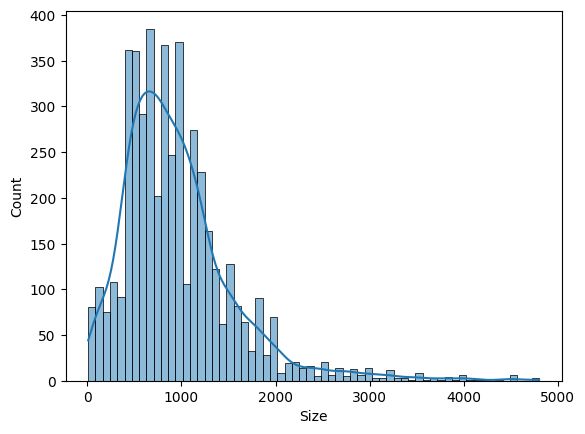

In [12]:
sns.histplot(data=df,x='Size',kde=True)

<Axes: xlabel='Rent', ylabel='Count'>

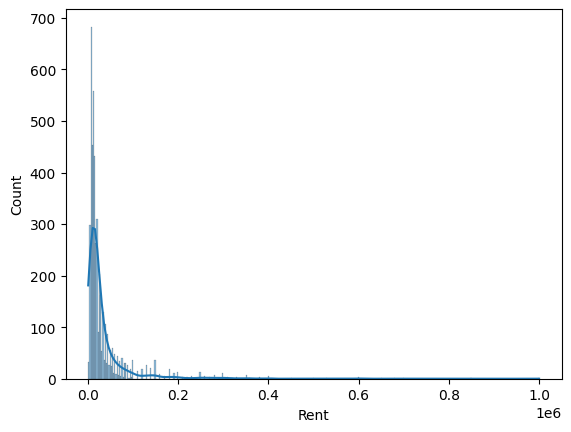

In [13]:
sns.histplot(data=df,x='Rent',kde=True)

<Axes: xlabel='Rent', ylabel='Size'>

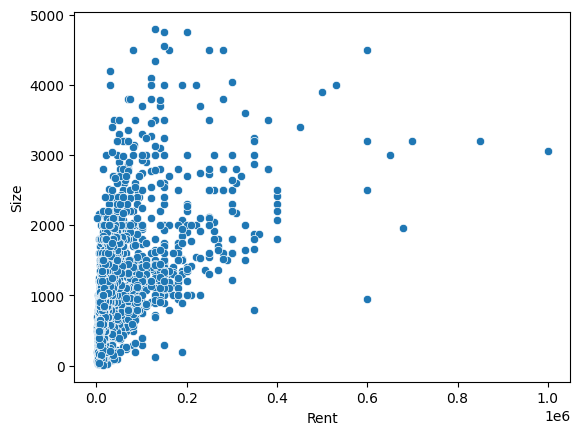

In [14]:
sns.scatterplot(data=df,x='Rent',y='Size')

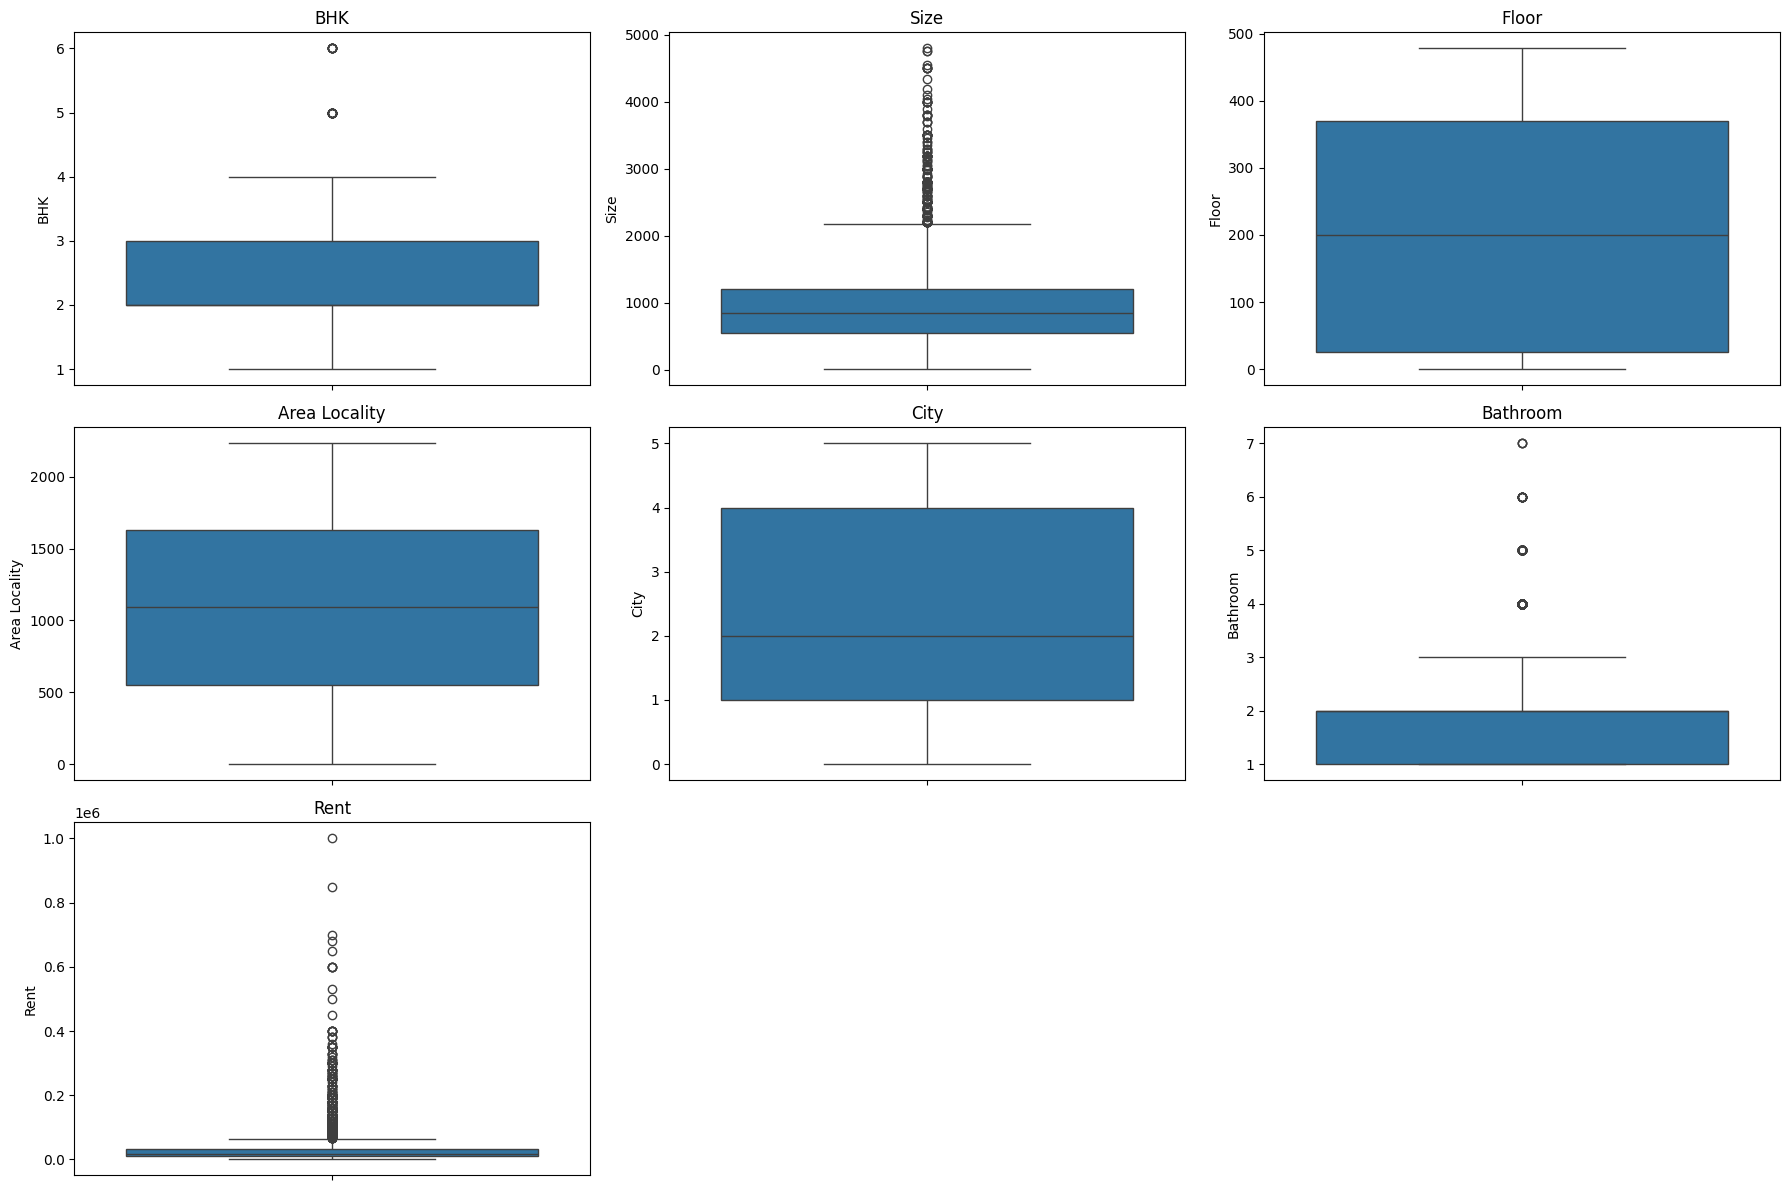

In [15]:
plt.figure(figsize=(18, 12))
for i, col in enumerate(df.columns):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'{col}')
plt.tight_layout()
plt.show()

In [16]:
print(f'Min size {df['Size'].min()}')
print(f'Max size {df['Size'].max()}')

Min size 10.0
Max size 4800.0


In [17]:
# Remove outliers in 'Size' using the IQR method
Q1 = df['Size'].quantile(0.325)
Q3 = df['Size'].quantile(0.675)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Size'] >= lower_bound) & (df['Size'] <= upper_bound)]

In [18]:
print(f'Min size {df['Size'].min()}')
print(f'Max size {df['Size'].max()}')

Min size 10.0
Max size 1771.0


Numbers became more real

<Axes: ylabel='Rent'>

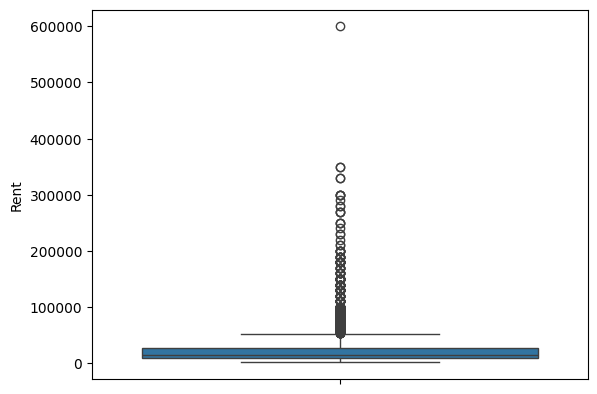

In [19]:
sns.boxplot(y=df[col])

In [20]:
df.shape

(4303, 7)

In [21]:
# Split features and target
X = df.drop(columns=['Rent'])  # Features
y = df['Rent']  # Target variable

In [22]:
# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler() # Standardize features by removing the mean and scaling to unit variance
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train) # same scaler used for y_train is used for y_test
y_test = scaler_y.transform(y_test)

In [25]:
 
def build_model():
    model = Sequential([
        Flatten(input_shape=(X_train.shape[1],)),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.005),
        loss='mean_squared_error',
        metrics=['mean_absolute_error', 'mean_squared_error']
    )
    return model


In [26]:
model=build_model()
model.summary()

c:\Users\mrtat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 11,649 (45.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [27]:
print("\nTraining the model...")
history = model.fit(
    X_train, y_train,
    epochs=150,  # Try more epochs for better convergence
    batch_size=32,
    validation_split=0.2,
    shuffle=True,
    verbose=2,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ]
)


Training the model...
Epoch 1/150
87/87 - 3s - 34ms/step - loss: 0.9120 - mean_absolute_error: 0.5821 - mean_squared_error: 0.9120 - val_loss: 0.5415 - val_mean_absolute_error: 0.4521 - val_mean_squared_error: 0.5415
Epoch 2/150
87/87 - 0s - 4ms/step - loss: 0.6097 - mean_absolute_error: 0.4187 - mean_squared_error: 0.6097 - val_loss: 0.3008 - val_mean_absolute_error: 0.3191 - val_mean_squared_error: 0.3008
Epoch 3/150
87/87 - 0s - 4ms/step - loss: 0.5636 - mean_absolute_error: 0.4014 - mean_squared_error: 0.5636 - val_loss: 0.3133 - val_mean_absolute_error: 0.3334 - val_mean_squared_error: 0.3133
Epoch 4/150
87/87 - 0s - 4ms/step - loss: 0.5336 - mean_absolute_error: 0.3708 - mean_squared_error: 0.5336 - val_loss: 0.2980 - val_mean_absolute_error: 0.3094 - val_mean_squared_error: 0.2980
Epoch 5/150
87/87 - 0s - 4ms/step - loss: 0.4954 - mean_absolute_error: 0.3489 - mean_squared_error: 0.4954 - val_loss: 0.2828 - val_mean_absolute_error: 0.2975 - val_mean_squared_error: 0.2828
Epoch 

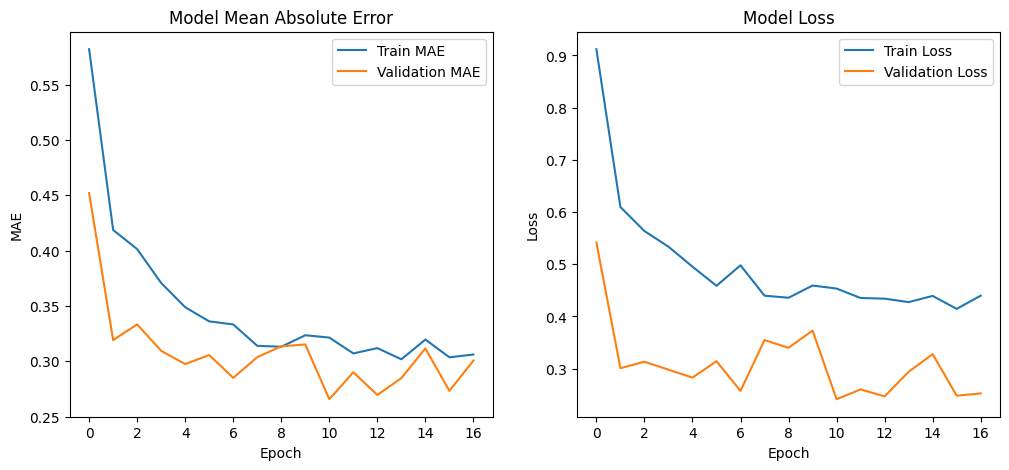

In [28]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['mean_absolute_error'], label='Train MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE')
plt.title('Model Mean Absolute Error')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [33]:
history.history.keys()

dict_keys(['loss', 'mean_absolute_error', 'mean_squared_error', 'val_loss', 'val_mean_absolute_error', 'val_mean_squared_error'])

In [29]:
# Show the last value for each metric in the training history
{key: value[-1] for key, value in history.history.items()}

{'loss': 0.43982234597206116,
 'mean_absolute_error': 0.3061102628707886,
 'mean_squared_error': 0.43982234597206116,
 'val_loss': 0.2525200843811035,
 'val_mean_absolute_error': 0.30060043931007385,
 'val_mean_squared_error': 0.2525200843811035}